# Historical Natural Must: Calibration and Estimability

This notebook independently reproduces the calibration, Fisher information, eigen-direction and profile-likelihood workflow used in `fermentation_estimability_old_vs_lot1`, restricted to the historical `natural` medium.

## tl;dr

The numerical conclusions are generated below from a fresh medium-specific fit. The final report states which parameters are locally supported, which remain confounded, and how well the fitted model reproduces each observed state.

## Context & Methods

The core parameter block is re-estimated in log space using the same bounds, residual scaling and deterministic multistart as the reference notebook. The local Fisher information matrix is

$$
F(\theta) = J(\theta)^\mathsf{T} J(\theta),
$$

where $J$ is the Jacobian of scaled residuals with respect to log-parameters. Profile likelihood is used as a nonlinear check for `Kd0` and `qN`; the three-point grid is a screening profile, not a final confidence interval.

For natural must, actual temperature is reconstructed from all timestamped fragments. The external process archive has priority; repository copies fill missing, non-conflicting fragments. Filtered CO2 flow is stitched and audited, but its values are not fitted as cumulative CO2.

### Key Assumptions

- Secondary and aroma parameters are evaluated conditionally at the shared prior values; only the core fermentation block is re-estimated here.
- CO2 flow and cumulative CO2 production are different observables. Sensor values remain diagnostic until a gas-liquid observation layer is calibrated.
- Missing observations stay missing. They are never replaced with zeros.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image

from laboratory_2026 import run_estimability_historical_by_medium as analysis

MEDIUM = 'natural'
RESULTS = analysis.results_dir(MEDIUM)


## Run Analysis

In [2]:
analysis.run_medium_analysis(
    MEDIUM,
    profile_parameters=("Kd0", "qN"),
    grid_points=3,
    fit_nfev=300,
    profile_nfev=45,
    step=0.04,
)

[load] historical natural


[fit-core] historical_natural_only


[fim-core] historical_natural_only


[fim-extended] historical_natural_only


[profile] historical_natural_only: Kd0, qN


[fit-diagnostics] historical_natural_only


[done] historical natural analysis complete


## Data

In [3]:
batch_summary = pd.read_csv(RESULTS / "batch_summary.csv")
support = pd.read_csv(RESULTS / "measurement_support.csv")
display(batch_summary)
display(support)

,case,medium,batch,n_time,t_min_h,t_max_h,X0,Xd0,N0,G0,F0,E0,Gly0,n_core_obs,n_secondary_obs,pulses
0,historical_natural_only,natural,LAB004,89,0.0,163.0,0.3939,0.0093,0.23076,75.04,70.81,9.707652,0.99,81,26,N:68@0.08
1,historical_natural_only,natural,LAB005,89,0.0,163.0,0.4932,0.0159,0.22730,77.71,87.95,9.786576,1.09,81,26,N:68@0.08
2,historical_natural_only,natural,LAB006,114,0.0,211.0,0.0990,0.0276,0.22912,81.63,75.81,9.865500,1.17,93,30,N:99@0.08
3,historical_natural_only,natural,LAB007,82,0.0,160.0,0.2916,0.0009,0.23904,77.52,74.55,11.759676,0.89,84,50,N:65@0.08
4,historical_natural_only,natural,LAB008,82,0.0,160.0,0.2535,0.0033,0.23922,76.21,74.89,9.234108,0.85,84,50,N:65@0.08
5,historical_natural_only,natural,LAB009,82,0.0,160.0,0.3603,0.0009,0.23740,75.75,76.68,9.707652,0.75,77,46,N:41@0.08
6,historical_natural_only,natural,LAB010,101,0.0,187.0,0.9609,0.1128,0.22570,78.49,77.05,9.313032,1.25,38,8,N:79@0.08
7,historical_natural_only,natural,LAB011,87,0.0,163.0,1.0656,0.0381,0.22024,75.61,76.67,9.313032,1.25,34,8,N:72@0.08
8,historical_natural_only,natural,LAB012,88,0.0,163.0,0.8514,0.1209,0.22206,75.00,79.88,9.391956,1.27,36,8,N:72@0.08


,state,n_observations,n_batches_with_observations,used_in_core_fit,used_in_extended_fim
0,X,100,9,True,True
1,Xd,100,9,True,True
2,N,91,9,True,True
3,G,91,9,True,True
4,F,91,9,True,True
5,E,44,9,True,True
6,Gly,91,9,True,True
7,Pyr,91,9,False,True
8,AcAld,79,6,False,True
9,Acetate,50,6,False,True


### Process-Signal Audit

In [4]:
process_qc = pd.read_csv(RESULTS / "process_signal_qc.csv")
file_inventory = pd.read_csv(RESULTS / "process_file_inventory.csv")
temperature_alignment = pd.read_csv(RESULTS / "temperature_nominal_vs_sensor_at_model_times.csv")
display(process_qc)
display(file_inventory[["batch", "kind", "source", "part_number", "relative_path", "n_rows_valid", "timestamp_min", "timestamp_max"]])
display(temperature_alignment.groupby("batch")["sensor_minus_nominal_c"].agg(["mean", "std", "min", "max"]))

,batch,kind,n_raw_rows_in_horizon,n_resampled_rows,t_first_h,t_last_h,horizon_h,observed_hours_gap_capped_30min,coverage_fraction,max_gap_min,value_min,value_median,value_max,selected_external_rows,selected_fallback_rows,negative_fraction,zero_fraction,spike_flag_fraction
0,LAB004,temperature,167850,323,1.770278,163.000000,163.0,160.114444,0.982297,66.916667,16.9000,18.40000,21.9000,167850,0,NaN,NaN,NaN
1,LAB004,co2,55949,962,1.778333,162.999444,163.0,160.050000,0.981902,70.266667,-0.6254,3.68050,15.2242,55949,0,0.104148,0.099340,0.038285
2,LAB005,temperature,167825,323,1.781944,163.000000,163.0,160.090556,0.982151,67.650000,17.7000,18.40000,21.6000,167825,0,NaN,NaN,NaN
3,LAB005,co2,55944,962,1.786944,162.999444,163.0,160.035556,0.981813,70.616667,0.6163,5.97775,13.4441,55944,0,0.000000,0.000000,0.016552
4,LAB006,temperature,217853,418,1.789722,210.999444,211.0,208.075556,0.986140,68.050000,15.8000,16.50000,20.0000,217853,0,NaN,NaN,NaN
5,LAB006,co2,72592,1250,1.795278,210.998611,211.0,208.015000,0.985853,71.300000,0.2433,2.70660,8.8174,72592,0,0.000000,0.000000,0.014533
6,LAB007,temperature,142206,320,0.000833,159.999167,160.0,159.998333,0.999990,0.400000,17.4000,18.30000,21.2000,142206,0,NaN,NaN,NaN
7,LAB007,co2,48570,960,0.000278,159.998333,160.0,159.998056,0.999988,0.516667,-0.1793,4.41275,17.2742,48570,0,0.048343,0.021207,0.022874
8,LAB008,temperature,142207,320,0.000000,159.999444,160.0,159.999444,0.999997,0.400000,17.3000,18.30000,21.1000,142207,0,NaN,NaN,NaN
9,LAB008,co2,48570,960,0.000278,159.998333,160.0,159.998056,0.999988,0.516667,0.5750,4.49155,14.7117,48570,0,0.000000,0.000000,0.019498


,batch,kind,source,part_number,relative_path,n_rows_valid,timestamp_min,timestamp_max
0,LAB004,temperature,external_primary,1,Lote 2\LAB004\Temp_F1_lab004.csv,17346,2026-04-06 14:46:13,2026-04-07 07:13:27
1,LAB004,temperature,external_primary,2,Lote 2\LAB004\Temp_F1_lab004_PT2.csv,179381,2026-04-07 08:20:22,2026-04-14 11:39:40
2,LAB004,temperature,repository_fallback,2,Temp_F1_lab004_PT2.csv,179381,2026-04-07 08:20:22,2026-04-14 11:39:40
3,LAB004,temperature,repository_fallback,1,Desktop_CyT_Tablero_Proceso\Temp_F1_lab004.csv,17346,2026-04-06 14:46:13,2026-04-07 07:13:27
4,LAB004,co2,external_primary,1,Lote 2\LAB004\CO2_FILT_F1_lab004.csv,5779,2026-04-06 14:46:42,2026-04-07 07:13:18
5,LAB004,co2,external_primary,2,Lote 2\LAB004\CO2_FILT_F1_LAB004_PT2.csv,59771,2026-04-07 08:23:34,2026-04-14 11:39:51
6,LAB004,co2,repository_fallback,2,CO2_FILT_F1_LAB004_PT2.csv,59771,2026-04-07 08:23:34,2026-04-14 11:39:51
7,LAB004,co2,repository_fallback,1,Desktop_CyT_Tablero_Proceso\CO2_FILT_F1_lab004...,5779,2026-04-06 14:46:42,2026-04-07 07:13:18
8,LAB005,temperature,external_primary,1,Lote 2\LAB005\Temp_F2_lab005.csv,17333,2026-04-06 14:46:55,2026-04-07 07:13:24
9,LAB005,temperature,external_primary,2,Lote 2\LAB005\Temp_F2_LAB005_PT2.csv,179382,2026-04-07 08:21:03,2026-04-14 11:40:25


,mean,std,min,max
batch,,,,
LAB004,0.071429,0.219890,-0.3,0.4
LAB005,0.178571,0.286030,-0.4,0.4
LAB006,0.168750,0.157982,-0.1,0.4
LAB007,-0.657143,2.600211,-3.6,2.9
LAB008,-0.057143,0.282065,-0.6,0.4
LAB009,0.600000,2.389212,-3.4,3.1
LAB010,0.310000,0.251440,0.0,0.8
LAB011,0.637500,1.359556,-0.2,3.8
LAB012,-0.166667,0.772981,-1.7,0.6


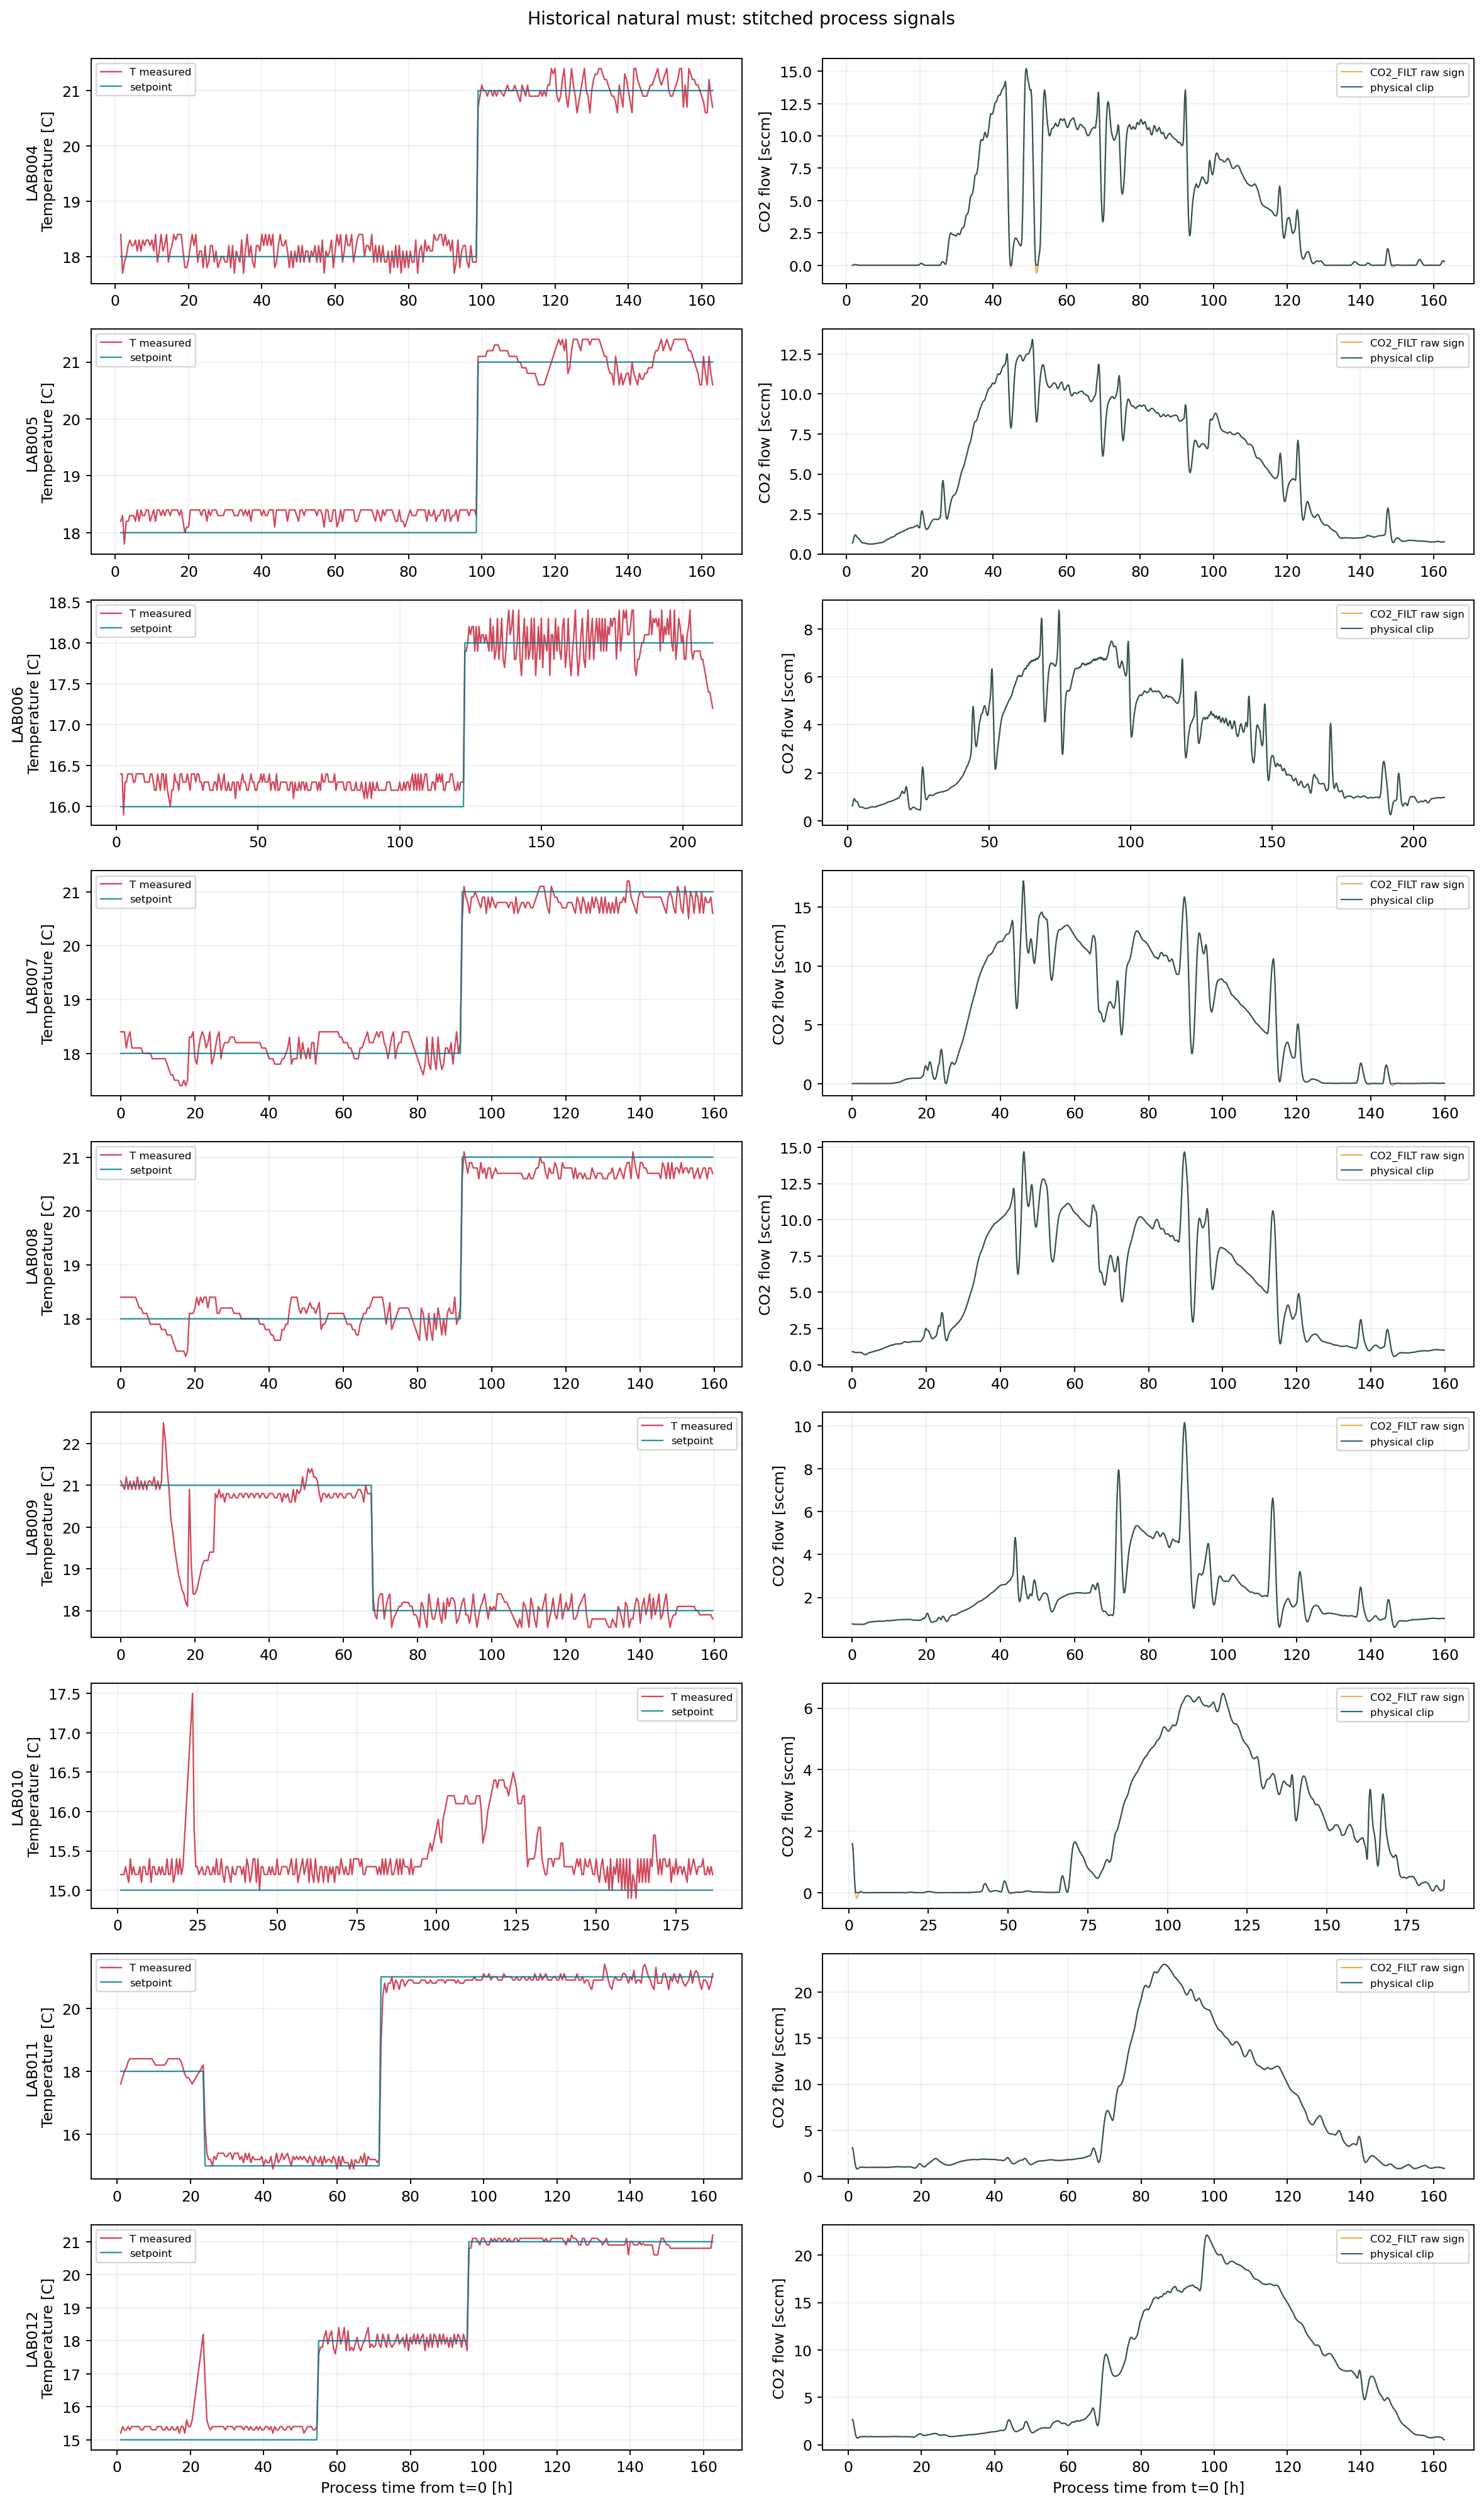

In [5]:
display(Image(filename=str(RESULTS / "figures" / "natural_process_signals.png")))

## Results

In [6]:
fit_candidates = pd.read_csv(RESULTS / "core_fit_candidate_summary.csv")
fit_summary = pd.read_csv(RESULTS / "core_fit_summary.csv")
fim_metrics = pd.read_csv(RESULTS / "fim_metrics.csv")
display(fit_candidates[["case", "seed", "final_wsse", "n_residuals", "nfev", "success"]])
display(fit_summary)
display(fim_metrics)

,case,seed,final_wsse,n_residuals,nfev,success
0,historical_natural_only,seed_default,11672.306726,608,20,True
1,historical_natural_only,qN_up_25pct,11672.294696,608,22,True
2,historical_natural_only,Kd0_up_2x,11672.119056,608,5,True
3,historical_natural_only,qN_up_25pct_Kd0_up_2x,11672.240034,608,8,True
4,historical_natural_only,profile_center_Kd0_nuisance,11672.084819,608,8,True
5,historical_natural_only,profile_center_Kd0_release,11672.084819,608,8,True
6,historical_natural_only,profile_center_qN_nuisance,11672.084819,608,8,True
7,historical_natural_only,profile_center_qN_release,11672.084819,608,8,True


,fit,n_batches,mediums,parameters,n_parameters,success,status,message,nfev,initial_wsse,final_wsse,n_residuals,dof,wsse_per_residual,wsse_per_dof,l2_lambda,l2_parameters,best_seed
0,historical_natural_only,9,natural,"mu0,qN,betaG0,betaF0,qEG,qEF,iG,iE,Kd0,gammaG0...",11,True,3,`xtol` termination condition is satisfied.,8,11672.084819,11672.084819,608,597,19.197508,19.551231,0.0,NaN,profile_center_Kd0_release


,logdet,min_eigenvalue,max_eigenvalue,min_relative_eigenvalue,condition_number,trace_inv,rank_1e-8,case,block,n_parameters
0,54.787452,0.000005,64485.648989,7.795836e-11,1.282736e+10,6.493135e+04,10,historical_natural_only,core_observed,11
1,90.288464,0.000005,75247.662922,6.702392e-11,1.492005e+10,7.258220e+04,16,historical_natural_only,core_secondary_observed_plus_co2_schedule,17
2,-57.333865,0.000000,75247.662922,0.000000e+00,1.000000e+12,1.668942e+06,16,historical_natural_only,full_26_candidate_plus_co2_schedule,26


### Parameter Estimability

In [7]:
estimability = pd.read_csv(RESULTS / "estimability_extended.csv")
display(estimability.sort_values("std_log_approx"))

,case,parameter,theta,std_log_approx,approx_95_multiplier,fim_diag,active_bound,classification
0,historical_natural_only,mu0,0.078728,0.012764,1.025333e+00,29341.358554,False,well_estimated
1,historical_natural_only,qN,0.021080,0.014625,1.029079e+00,21037.894502,False,well_estimated
14,historical_natural_only,kAldS_N,2.359888,0.029996,1.060556e+00,3597.865163,False,well_estimated
16,historical_natural_only,kAcStress,0.002616,0.034345,1.069634e+00,901.893372,False,well_estimated
4,historical_natural_only,qEG,1.712807,0.065427,1.136822e+00,26432.664332,False,well_estimated
9,historical_natural_only,gammaG0,0.115559,0.072589,1.152894e+00,9109.510907,False,well_estimated
11,historical_natural_only,kPyrS_N,0.850862,0.076377,1.161486e+00,512.067600,False,well_estimated
2,historical_natural_only,betaG0,0.428878,0.110838,1.242646e+00,3382.689692,False,well_estimated
7,historical_natural_only,iE,0.040168,0.112305,1.246222e+00,11683.835232,False,well_estimated
13,historical_natural_only,kPyrDrain,0.003591,0.145282,1.329432e+00,377.298576,False,well_estimated


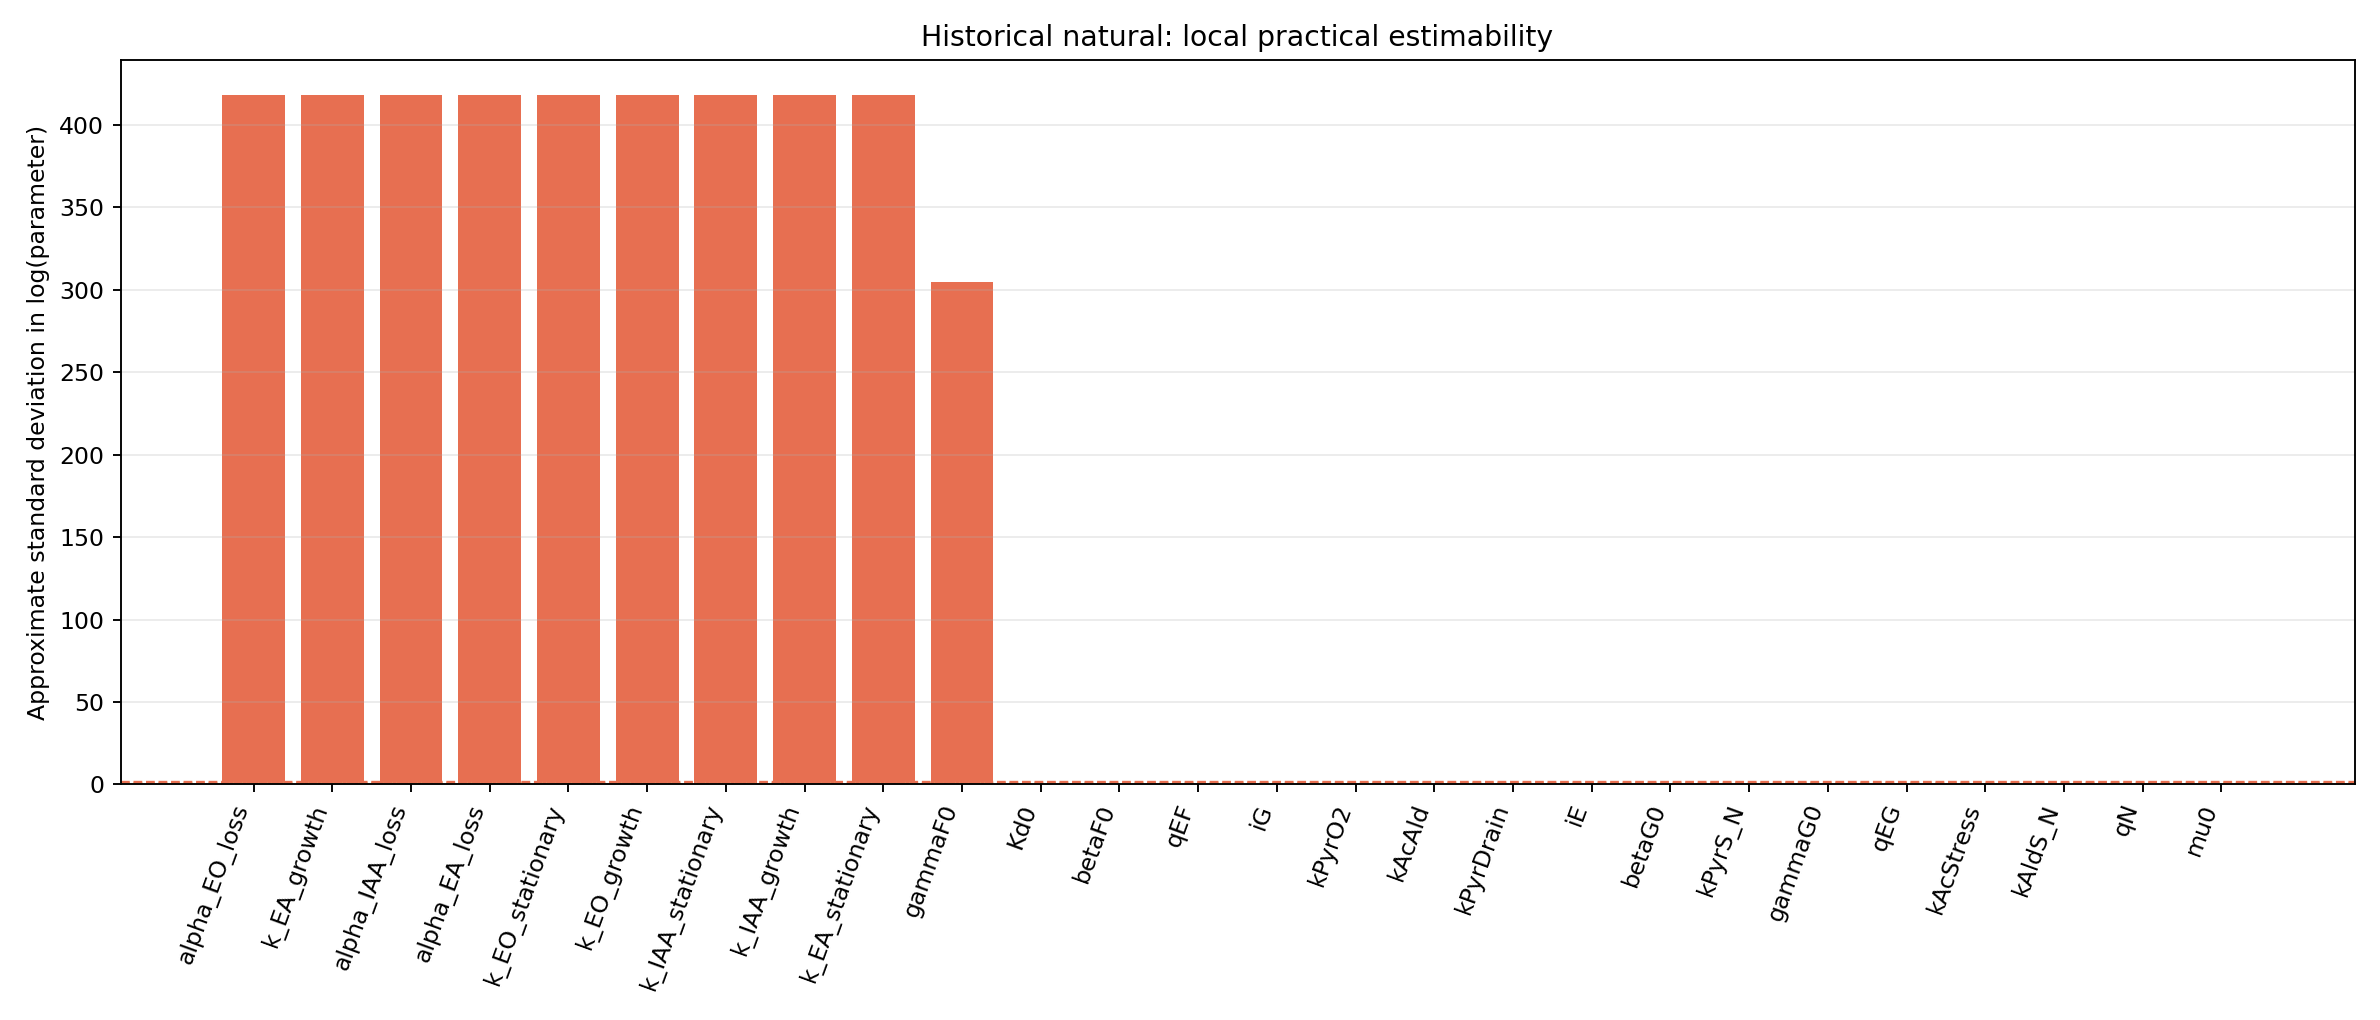

In [8]:
display(Image(filename=str(RESULTS / "figures" / "estimability_std_log.png")))

### Eigenvalue Diagnostics

,case,weak_direction,eigenvalue,dominant_parameters,dominant_abs_loadings
0,historical_natural_only,1,0.0,"k_EA_growth, alpha_EO_loss, kPyrS_N, qN, betaG...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
1,historical_natural_only,2,0.0,"k_EA_stationary, alpha_EO_loss, kPyrS_N, qN, b...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
2,historical_natural_only,3,0.0,"k_IAA_growth, alpha_EO_loss, kPyrS_N, qN, beta...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
3,historical_natural_only,4,0.0,"k_IAA_stationary, alpha_EO_loss, kPyrS_N, qN, ...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
4,historical_natural_only,5,0.0,"k_EO_growth, alpha_EO_loss, kPyrS_N, qN, betaG...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
5,historical_natural_only,6,0.0,"k_EO_stationary, alpha_EO_loss, kPyrS_N, qN, b...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
6,historical_natural_only,7,0.0,"alpha_EA_loss, alpha_EO_loss, kPyrS_N, qN, bet...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
7,historical_natural_only,8,0.0,"alpha_IAA_loss, alpha_EO_loss, qN, betaG0, bet...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"


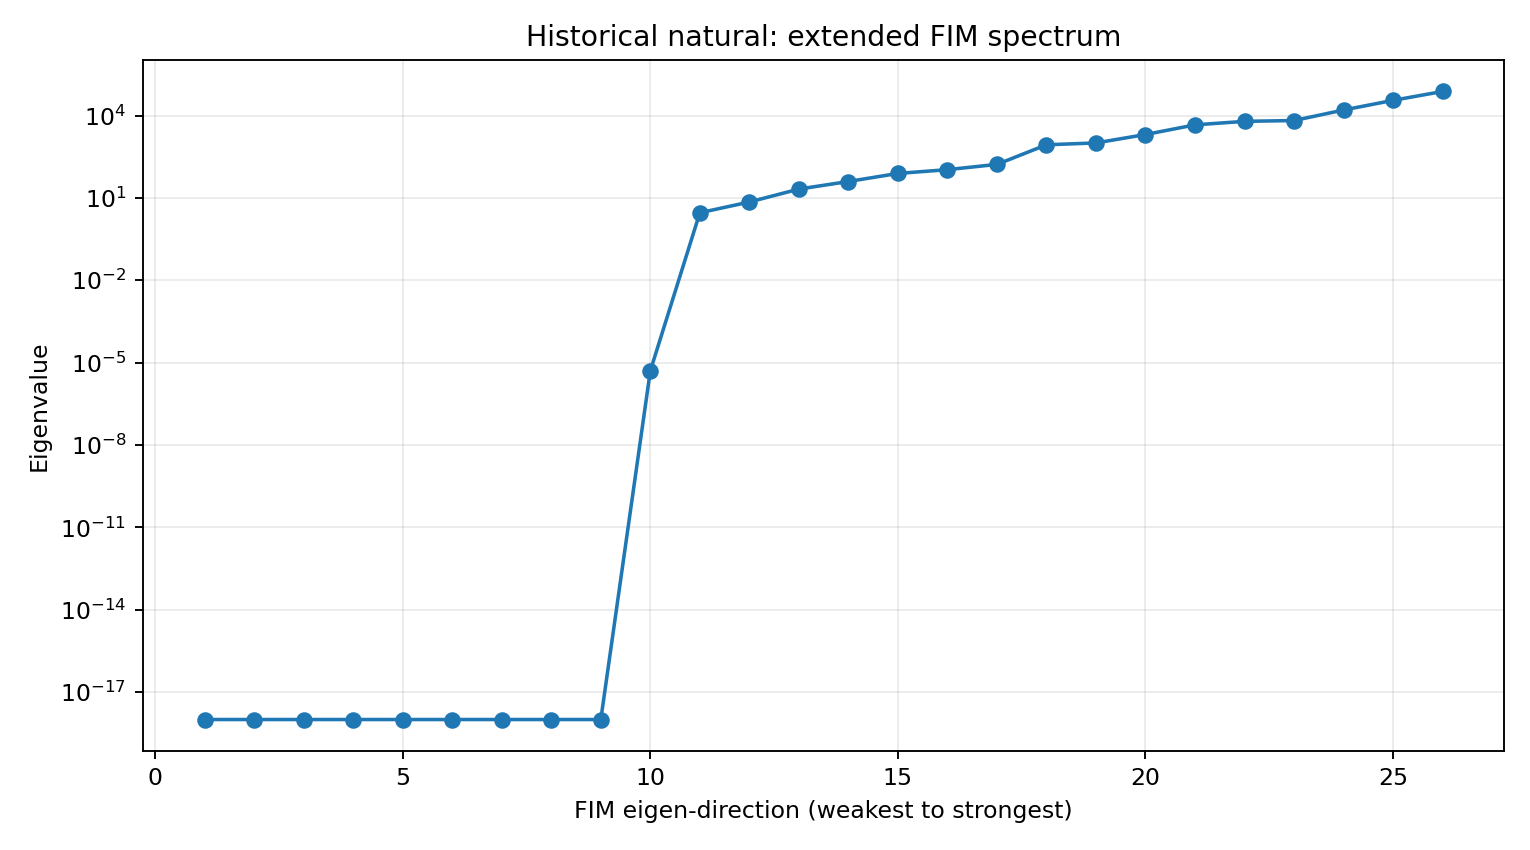

In [9]:
weak = pd.read_csv(RESULTS / "weak_directions_extended.csv")
display(weak)
display(Image(filename=str(RESULTS / "figures" / "extended_fim_eigenvalues.png")))

### Profile Likelihood

In [10]:
profile_summary = pd.read_csv(RESULTS / "profile_likelihood_summary_core.csv")
profile = pd.read_csv(RESULTS / "profile_likelihood_core.csv")
display(profile_summary)
display(profile)

,case,parameter,n_success,max_lr_stat,crosses_left_95,crosses_right_95,profile_identifiable_95,chi2_95_threshold
0,historical_natural_only,Kd0,4,6.693009,False,True,False,3.841459
1,historical_natural_only,qN,4,2195.536027,True,True,True,3.841459


,case,profiled_parameter,theta_hat,theta_value,success,objective,lr_stat,chi2_95_threshold,error
0,historical_natural_only,Kd0,0.00015,0.000100,True,11672.703639,0.618819,3.841459,NaN
1,historical_natural_only,Kd0,0.00015,0.000150,True,11672.084819,0.000000,3.841459,NaN
2,historical_natural_only,Kd0,0.00015,0.000200,True,11672.836704,0.751884,3.841459,NaN
3,historical_natural_only,Kd0,0.00015,0.000300,True,11678.777828,6.693009,3.841459,NaN
4,historical_natural_only,qN,0.02108,0.010540,True,13867.620846,2195.536027,3.841459,NaN
5,historical_natural_only,qN,0.02108,0.021080,True,11672.084819,0.000000,3.841459,NaN
6,historical_natural_only,qN,0.02108,0.026350,True,11774.291731,102.206912,3.841459,NaN
7,historical_natural_only,qN,0.02108,0.042161,True,12296.870569,624.785750,3.841459,NaN


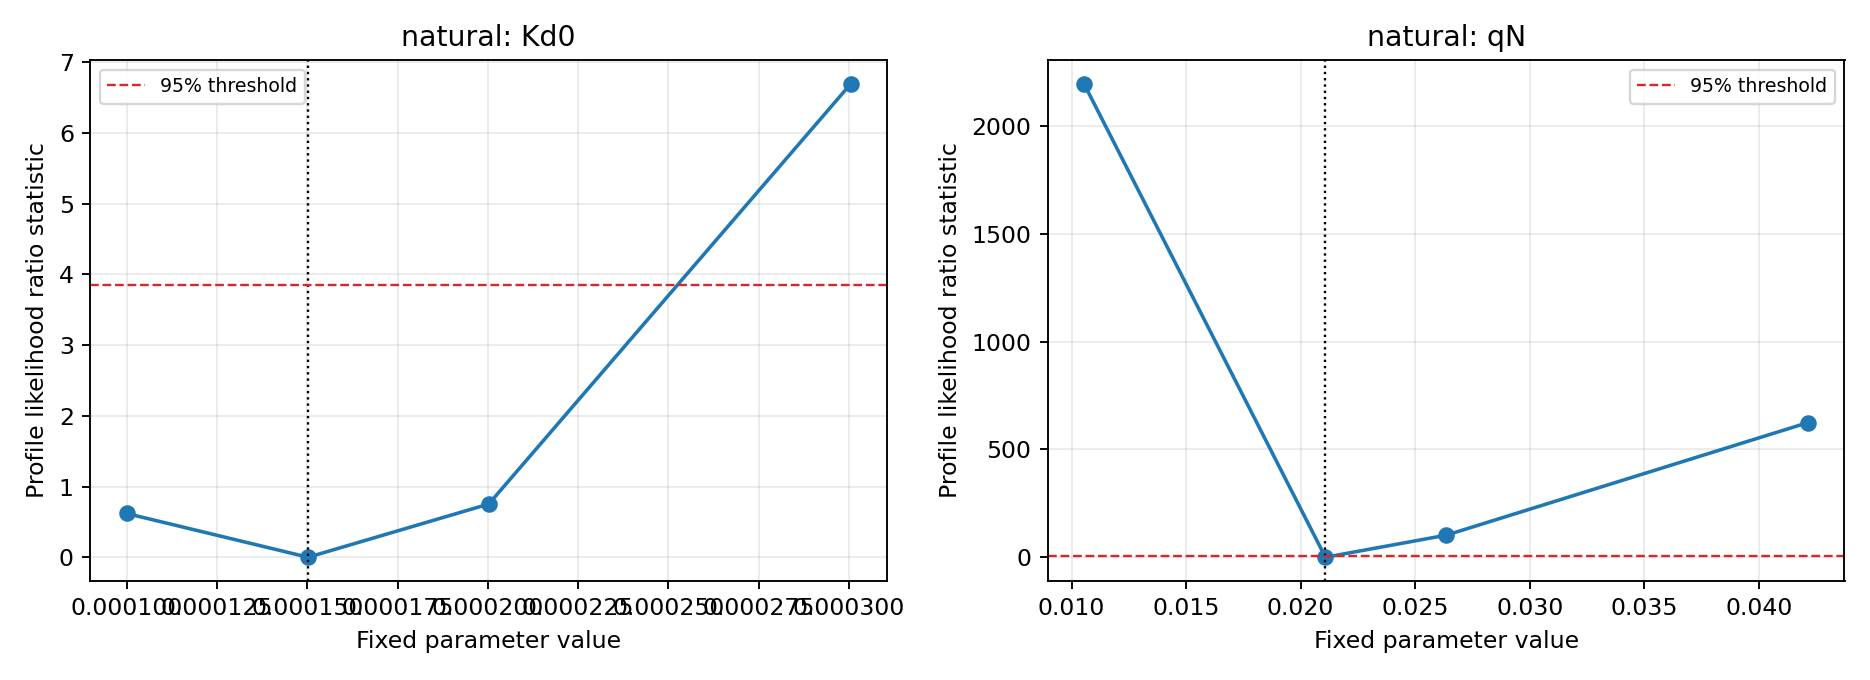

In [11]:
display(Image(filename=str(RESULTS / "figures" / "profile_likelihood.png")))

### Curve-Fit Checks

In [12]:
core_curve_metrics = pd.read_csv(RESULTS / "core_fit_metrics_by_batch_state.csv")
secondary_curve_metrics = pd.read_csv(RESULTS / "secondary_fit_metrics_by_batch_state.csv")
display(core_curve_metrics.groupby("state").agg(n=("n", "sum"), median_RMSE=("rmse", "median"), max_RMSE=("rmse", "max")))
display(secondary_curve_metrics.groupby("state").agg(n=("n", "sum"), median_RMSE=("rmse", "median"), max_RMSE=("rmse", "max")))

,n,median_RMSE,max_RMSE
state,,,
E,44,7.764022,20.978815
F,91,6.315649,27.939290
G,91,4.954037,26.528860
Gly,91,0.800133,2.011538
N,91,0.039878,0.192096
X,100,0.464012,0.853869
Xd,100,0.101623,0.178621


,n,median_RMSE,max_RMSE
state,,,
AcAld,79,33.602589,47.982001
Acetate,50,0.121128,0.150740
O2,32,0.361753,0.391118
Pyr,91,13.152478,18.848452


## Takeaways

In [13]:
report = (RESULTS / "estimability_historical_natural_report.md").read_text(encoding="utf-8")
print(report)

# Historical natural estimability analysis

## Scope

This is an independent calibration and estimability analysis using only the historical `natural` medium subset. It is not a row-filtered view of the joint historical fit.

Actual temperature records replace the nominal temperature input. Valid CO2 sensor times enter the extended FIM as an online measurement schedule, while CO2 values remain diagnostic.

The core kinetic block is re-estimated. Secondary and aroma parameters are evaluated conditionally at the shared prior values, matching the logic of `fermentation_estimability_old_vs_lot1`.

## Core fit

| fit                     |   n_batches | mediums   | parameters                                             |   n_parameters | success   |   status | message                                    |   nfev |   initial_wsse |   final_wsse |   n_residuals |   dof |   wsse_per_residual |   wsse_per_dof |   l2_lambda |   l2_parameters | best_seed                  |
|:-----------------------